In [23]:
import importlib
import miaw
importlib.reload(miaw)
from miaw import FFNN
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OneHotEncoder
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils import check_random_state
from sklearn.metrics import accuracy_score


In [24]:
# Extract the dataset
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

random_state = check_random_state(0)
permutation = random_state.permutation(X.shape[0])
X = X[permutation]
y = y[permutation]
X = X.reshape((X.shape[0], -1))

encoder = OneHotEncoder(sparse_output=False, categories='auto')
y_encoded = encoder.fit_transform(y.reshape(-1, 1))
# train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [25]:
print(X_train.shape)
print(X_val.shape)

(56000, 784)
(14000, 784)


# Analysis of Parameters

### 1. Learning Rate

Epoch 1/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 108657.06it/s]


Epoch 1 Completed - Train Loss: 1.5270 - Val Loss: 0.7316


Epoch 2/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 118120.12it/s]


Epoch 2 Completed - Train Loss: 0.5816 - Val Loss: 0.5492


Epoch 3/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 113654.29it/s]


...

Epoch 8 Completed - Train Loss: 0.2583 - Val Loss: 0.3251


Epoch 9/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 106061.01it/s]


Epoch 9 Completed - Train Loss: 0.2433 - Val Loss: 0.3160


Epoch 10/10: 100%|████████████████████████████████████████| 56000/56000 [00:00<00:00, 110655.30it/s]


Epoch 10 Completed - Train Loss: 0.2294 - Val Loss: 0.3031
Accuracy: 92.26%


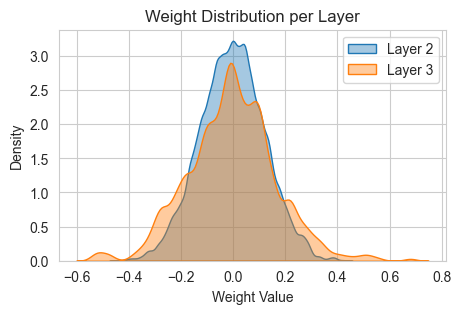

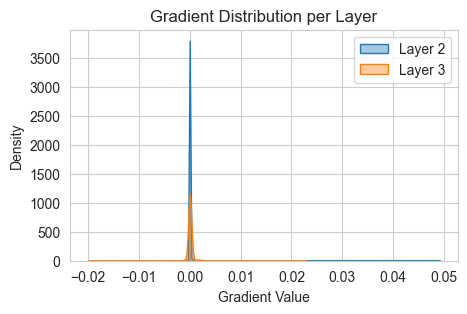

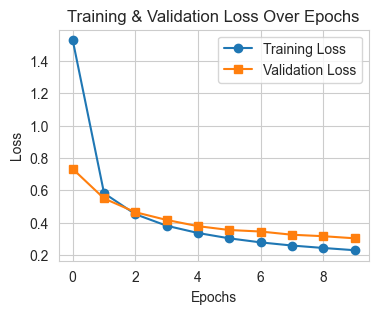

Accuracy: 92.26%


In [26]:
miawlenteraModel = FFNN([784,128,64,10], ['relu','relu','softmax'],loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

history = miawlenteraModel.fit(X_train, y_train, X_val, y_val, epochs=10, batch_size=64, lr=0.05, verbose=1)

miaw_pred = miawlenteraModel.predict(X_val)
y_val_labels = np.argmax(y_val, axis=1)
# miaw_pred_labels = np.argmax(miaw_pred, axis=1)

accuracy = accuracy_score(y_val_labels, miaw_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

miawlenteraModel.plot_distribution([1,2], plot_type="weight")
miawlenteraModel.plot_distribution([1,2], plot_type="gradient")
miawlenteraModel.plot_loss_history(history)

miawlenteraModel.save('./models/lr1.json')

testload = FFNN.load('./models/lr1.json')

miaw_p = testload.predict(X_val)
y_val_labels = np.argmax(y_val,axis=1)
miaw_pred_labels = np.argmax(miaw_p, axis=1)

accuracy_new = accuracy_score(y_val_labels,miaw_pred_labels)
print(f"Accuracy: {accuracy_new * 100:.2f}%")


Epoch 1/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 118136.22it/s]


Epoch 1 Completed - Train Loss: 3.9375 - Val Loss: 2.1267


Epoch 2/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 119675.02it/s]


Epoch 2 Completed - Train Loss: 1.5842 - Val Loss: 1.3699


Epoch 3/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 115539.43it/s]


...

Epoch 8 Completed - Train Loss: 0.4847 - Val Loss: 0.5837


Epoch 9/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 103284.22it/s]


Epoch 9 Completed - Train Loss: 0.4500 - Val Loss: 0.5546


Epoch 10/10: 100%|████████████████████████████████████████| 56000/56000 [00:00<00:00, 124138.73it/s]


Epoch 10 Completed - Train Loss: 0.4209 - Val Loss: 0.5306
Accuracy: 88.10%


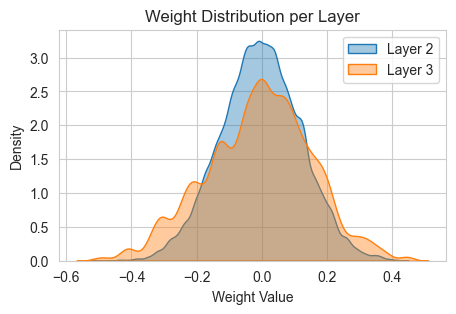

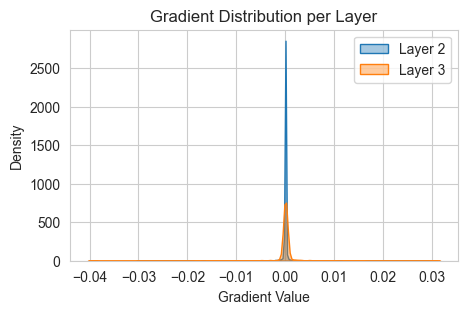

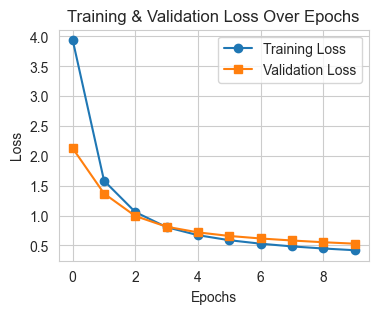

Accuracy: 88.10%


In [27]:
miawlenteraModel = FFNN([784,128,64,10], ['relu','relu','softmax'],loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

history = miawlenteraModel.fit(X_train, y_train, X_val, y_val, epochs=10, batch_size=64, lr=0.01, verbose=1)

miaw_pred = miawlenteraModel.predict(X_val)
y_val_labels = np.argmax(y_val, axis=1)
# miaw_pred_labels = np.argmax(miaw_pred, axis=1)

accuracy = accuracy_score(y_val_labels, miaw_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

miawlenteraModel.plot_distribution([1,2], plot_type="weight")
miawlenteraModel.plot_distribution([1,2], plot_type="gradient")
miawlenteraModel.plot_loss_history(history)

miawlenteraModel.save('./models/lr2.json')

testload = FFNN.load('./models/lr2.json')

miaw_p = testload.predict(X_val)
y_val_labels = np.argmax(y_val,axis=1)
miaw_pred_labels = np.argmax(miaw_p, axis=1)

accuracy_new = accuracy_score(y_val_labels,miaw_pred_labels)
print(f"Accuracy: {accuracy_new * 100:.2f}%")


Epoch 1/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 115984.04it/s]


Epoch 1 Completed - Train Loss: 10.7952 - Val Loss: 6.4669


Epoch 2/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 111083.74it/s]


Epoch 2 Completed - Train Loss: 5.1486 - Val Loss: 4.4875


Epoch 3/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 117461.71it/s]


...

Epoch 8 Completed - Train Loss: 1.8941 - Val Loss: 1.9273


Epoch 9/10: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 120132.26it/s]


Epoch 9 Completed - Train Loss: 1.7175 - Val Loss: 1.7570


Epoch 10/10: 100%|████████████████████████████████████████| 56000/56000 [00:00<00:00, 100281.54it/s]


Epoch 10 Completed - Train Loss: 1.5654 - Val Loss: 1.6141
Accuracy: 73.85%


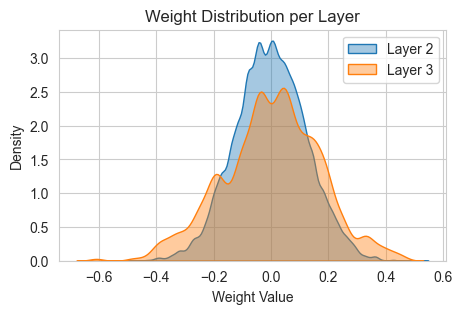

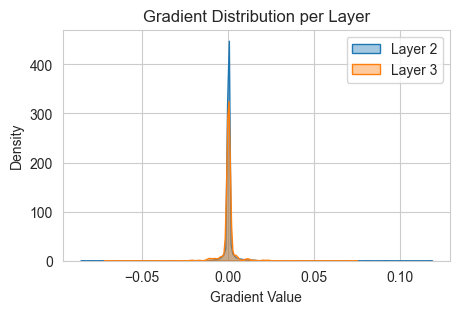

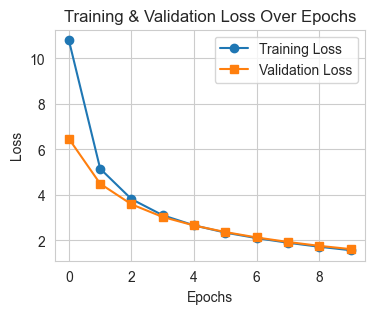

Accuracy: 73.85%


In [28]:
miawlenteraModel = FFNN([784,128,64,10], ['relu','relu','softmax'],loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

history = miawlenteraModel.fit(X_train, y_train, X_val, y_val, epochs=10, batch_size=64, lr=0.001, verbose=1)

miaw_pred = miawlenteraModel.predict(X_val)
y_val_labels = np.argmax(y_val, axis=1)
# miaw_pred_labels = np.argmax(miaw_pred, axis=1)

accuracy = accuracy_score(y_val_labels, miaw_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

miawlenteraModel.plot_distribution([1,2], plot_type="weight")
miawlenteraModel.plot_distribution([1,2], plot_type="gradient")
miawlenteraModel.plot_loss_history(history)

miawlenteraModel.save('./models/lr3.json')

testload = FFNN.load('./models/lr3.json')

miaw_p = testload.predict(X_val)
y_val_labels = np.argmax(y_val,axis=1)
miaw_pred_labels = np.argmax(miaw_p, axis=1)

accuracy_new = accuracy_score(y_val_labels,miaw_pred_labels)
print(f"Accuracy: {accuracy_new * 100:.2f}%")


As